# 03 — Clustering & Temporal Pattern Analysis

**Phase 1 of the thesis (RQ1):** Construct subsystem-aware feature representations from recurring anomaly patterns.

**Methodology (from proposal):**
1. Detect anomalous windows via z-score thresholding on supervised features
2. Build binary sensor activation matrix (which sensors deviate in which windows)
3. Cluster anomalous windows using hierarchical clustering (Ward/Jaccard) to find recurring patterns
4. Characterize each cluster: which sensors, which subsystems, failure enrichment
5. Temporal pattern analysis: when do clusters appear relative to failures, lead times
6. Map clusters to subsystem-aware feature groups for expert verification

**Input:** `outputs/supervised_datasets/6m_22326_shift/` (6-min windows, 6.2h label horizon — default config from Helm)

**Output:** Cluster definitions and subsystem mappings for Phase 2 modeling

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform

ROOT = Path(r"C:\Users\Emırhan\Desktop\MASTER THESIS\Kurtulus-thesis")
sys.path.insert(0, str(ROOT))

DATASET_DIR = ROOT / "outputs" / "supervised_datasets" / "6m_22326_shift"
PLOTS_DIR = ROOT / "outputs" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

Z_THRESH = 2.0
MIN_ACTIVATED_SENSORS = 3  # minimum sensors to count as anomalous window

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 6)})

## 1. Load Dataset & Extract Sensor Names

In [2]:
train = pd.read_parquet(DATASET_DIR / "train.parquet")
test = pd.read_parquet(DATASET_DIR / "test.parquet")

exclude = {"window_end", "label", "days_since_last_failure", "days_since_last_revision"}
feature_cols = [c for c in train.columns if c not in exclude]

suffixes = ("_min", "_max", "_mean", "_sum", "_active_s", "_flips")
sensors = sorted({col[: -len(suf)] for col in feature_cols for suf in suffixes if col.endswith(suf)})

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Feature columns: {len(feature_cols)}, Base sensors: {len(sensors)}")
print(f"Normal: {(train['label']==0).sum()}, Pre-failure: {(train['label']==1).sum()}")

Train: (40517, 348), Test: (21554, 348)
Feature columns: 344, Base sensors: 98
Normal: 39999, Pre-failure: 518


## 2. Subsystem Mapping

Map each sensor to its functional subsystem using domain knowledge from `src/config.py`.

In [3]:
from src.config import SUBSYSTEMS

sensor_to_subsystem = {}
for subsystem, cols in SUBSYSTEMS.items():
    for col in cols:
        sensor_to_subsystem[col] = subsystem

# Check coverage
mapped = [s for s in sensors if s in sensor_to_subsystem]
unmapped = [s for s in sensors if s not in sensor_to_subsystem]
print(f"Mapped to subsystem: {len(mapped)}/{len(sensors)}")
if unmapped:
    print(f"Unmapped sensors: {unmapped}")

# Subsystem distribution
subsystem_counts = pd.Series([sensor_to_subsystem.get(s, 'Unknown') for s in sensors]).value_counts()
print(f"\nSensors per subsystem:")
print(subsystem_counts.to_string())

Mapped to subsystem: 98/98

Sensors per subsystem:
Brake       67
Leveling    18
Context      5
APU          4
Traction     4


## 3. Z-Score Anomaly Detection & Activation Matrix

Compute z-scores relative to normal-operation statistics (label=0). A sensor is "activated" in a window if any of its features has |z| > threshold.

**Note:** We use `MIN_ACTIVATED_SENSORS = 3` here (vs. NB02 which uses >= 1). This stricter threshold filters out windows with only 1-2 mildly anomalous sensors, focusing the clustering on windows with clear multi-sensor anomaly patterns. This avoids noise-dominated clusters and produces more interpretable subsystem groupings.

In [4]:
normal = train[train["label"] == 0]

# Compute normal statistics and z-scores
z_scores = pd.DataFrame(index=train.index)
for col in feature_cols:
    mu = normal[col].mean()
    sd = normal[col].std()
    if sd < 1e-10:
        z_scores[col] = 0.0
    else:
        z_scores[col] = (train[col] - mu) / sd

# Build binary activation matrix: windows x sensors
activation = pd.DataFrame(0, index=train.index, columns=sensors)
for sensor in sensors:
    sensor_feats = [c for c in feature_cols if any(c == sensor + suf for suf in suffixes)]
    if sensor_feats:
        max_abs_z = z_scores[sensor_feats].abs().max(axis=1)
        activation[sensor] = (max_abs_z > Z_THRESH).astype(int)

n_activated = activation.sum(axis=1)
print(f"Activation matrix: {activation.shape}")
print(f"Windows with >= 1 sensor activation: {(n_activated > 0).sum()} ({100*(n_activated > 0).mean():.1f}%)")
print(f"Windows with >= {MIN_ACTIVATED_SENSORS} sensors: {(n_activated >= MIN_ACTIVATED_SENSORS).sum()}")

C:\Users\Emırhan\AppData\Local\Temp\ipykernel_17308\4276532518.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  z_scores[col] = (train[col] - mu) / sd
C:\Users\Emırhan\AppData\Local\Temp\ipykernel_17308\4276532518.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  z_scores[col] = (train[col] - mu) / sd
C:\Users\Emırhan\AppData\Local\Temp\ipykernel_17308\4276532518.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

Activation matrix: (40517, 98)
Windows with >= 1 sensor activation: 28663 (70.7%)
Windows with >= 3 sensors: 19689


## 4. Window Classification

Classify windows into 4 categories: (anomalous vs clean) x (normal vs pre-failure).

In [5]:
is_anomalous = n_activated >= MIN_ACTIVATED_SENSORS
labels = train["label"].values

categories = pd.DataFrame({
    "Category": [
        "Clean Normal (no anomaly, label=0)",
        "Anomalous Normal (anomaly, label=0)",
        "Clean Pre-failure (no anomaly, label=1)",
        "Anomalous Pre-failure (anomaly, label=1)",
    ],
    "Count": [
        int(((~is_anomalous) & (labels == 0)).sum()),
        int(((is_anomalous) & (labels == 0)).sum()),
        int(((~is_anomalous) & (labels == 1)).sum()),
        int(((is_anomalous) & (labels == 1)).sum()),
    ],
})
categories["% of Total"] = (100 * categories["Count"] / len(train)).round(1)

# Failure enrichment: what fraction of anomalous windows are pre-failure vs baseline?
baseline_rate = labels.mean()
anomalous_failure_rate = labels[is_anomalous].mean() if is_anomalous.any() else 0

print(f"Baseline failure rate: {100*baseline_rate:.2f}%")
print(f"Failure rate among anomalous windows: {100*anomalous_failure_rate:.2f}%")
print(f"Enrichment factor: {anomalous_failure_rate/baseline_rate:.1f}x\n")
categories

Baseline failure rate: 1.28%
Failure rate among anomalous windows: 2.37%
Enrichment factor: 1.9x



,Category,Count,% of Total
0,"Clean Normal (no anomaly, label=0)",20776,51.3
1,"Anomalous Normal (anomaly, label=0)",19223,47.4
2,"Clean Pre-failure (no anomaly, label=1)",52,0.1
3,"Anomalous Pre-failure (anomaly, label=1)",466,1.2


## 5. Sensor Activation Rates

Which sensors are most frequently activated across all windows? How does activation differ between normal and pre-failure windows?

In [6]:
# Activation rates: overall, normal-only, pre-failure-only
rate_overall = activation.mean()
rate_normal = activation[labels == 0].mean()
rate_prefailure = activation[labels == 1].mean()

sensor_rates = pd.DataFrame({
    "sensor": sensors,
    "subsystem": [sensor_to_subsystem.get(s, "Unknown") for s in sensors],
    "rate_overall": rate_overall.values,
    "rate_normal": rate_normal.values,
    "rate_prefailure": rate_prefailure.values,
})
sensor_rates["enrichment"] = (sensor_rates["rate_prefailure"] / sensor_rates["rate_normal"].clip(lower=1e-6))
sensor_rates = sensor_rates.sort_values("enrichment", ascending=False)

print("Top 20 sensors by pre-failure enrichment (rate_prefailure / rate_normal):")
sensor_rates.head(20)

Top 20 sensors by pre-failure enrichment (rate_prefailure / rate_normal):


,sensor,subsystem,rate_overall,rate_normal,rate_prefailure,enrichment
97,TRAIN_SPEED_ACTUAL,Context,0.000123,0.000100,0.001931,19.304537
78,MW3_SPRING_BRAKE_PRESSURE_BOGIE2,Brake,0.030654,0.025851,0.401544,15.533244
53,MW2_ENERGY_BRAKING_RESISTANCE,Traction,0.001876,0.001675,0.017375,10.372587
67,MW3_ENERGY_BRAKING_RESISTANCE,Traction,0.001950,0.001750,0.017375,9.928047
69,MW3_LOAD_PRESSURE_BOGIE2,Leveling,0.037268,0.033901,0.297297,8.769613
81,MW4_ENERGY_BRAKING_RESISTANCE,Traction,0.002419,0.002225,0.017375,7.808577
7,CW1_MAIN_RESERVOIR_PRESSURE,APU,0.017672,0.016325,0.121622,7.449837
25,CW2_MAIN_RESERVOIR_PRESSURE,APU,0.015623,0.014650,0.090734,6.193264
84,MW4_LOAD_SIGNAL,Leveling,0.093467,0.088927,0.444015,4.993020
66,MW3_BRAKE_CYLINDER_PRESSURE_BOGIE2,Brake,0.147592,0.141504,0.617761,4.365690


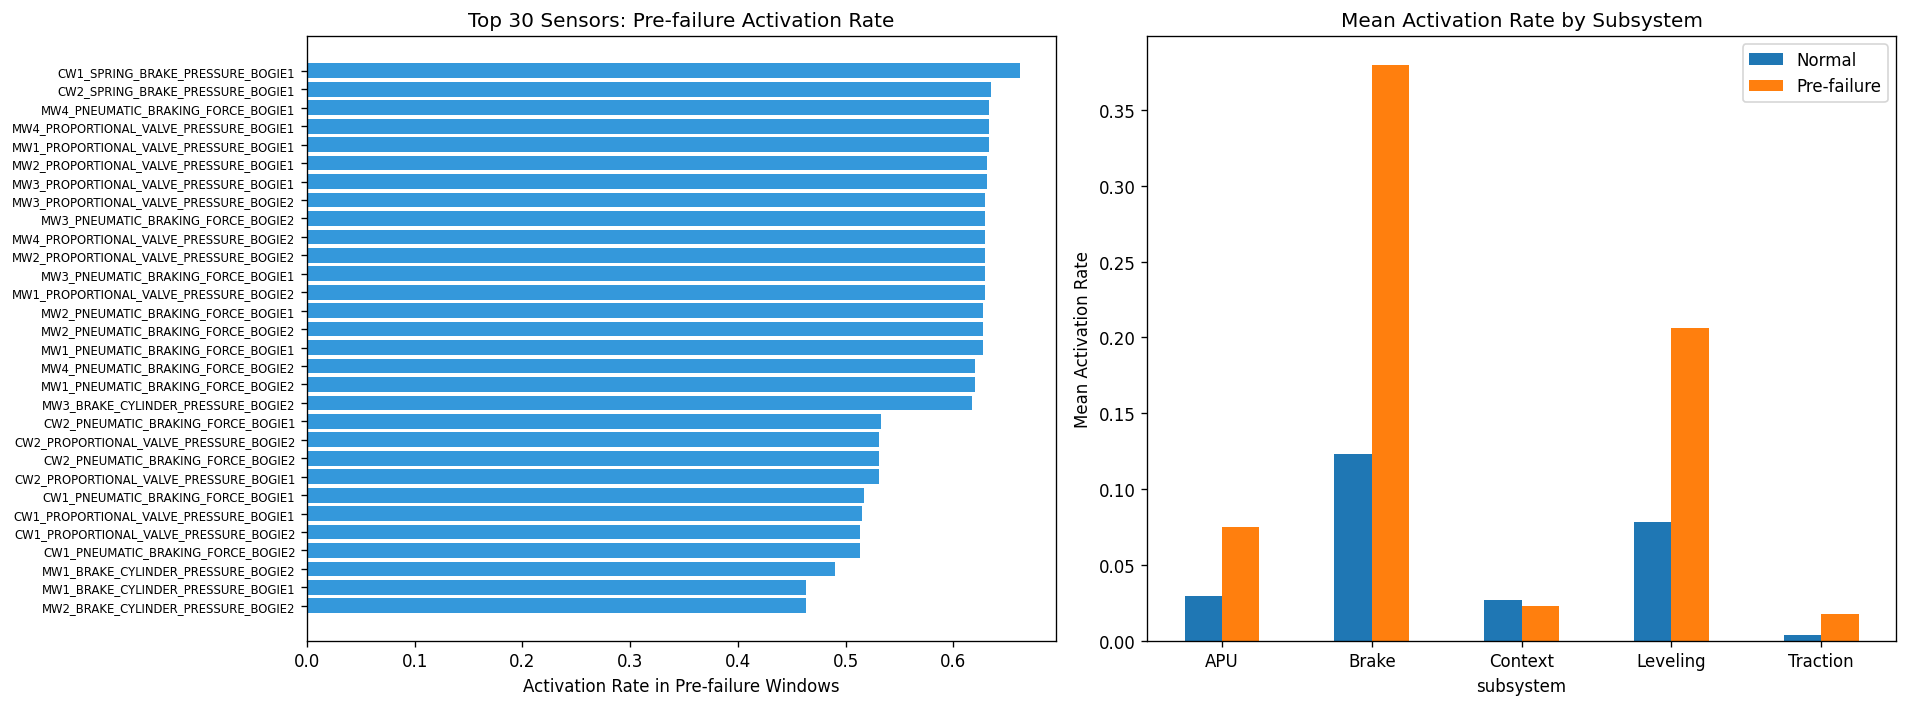

In [7]:
# Plot: activation rates by subsystem
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 30 sensors by pre-failure activation rate
top30 = sensor_rates.nlargest(30, "rate_prefailure")
colors = top30["subsystem"].map({
    "APU": "#e74c3c", "Brake": "#3498db", "Leveling": "#2ecc71",
    "Traction": "#f39c12", "Context": "#9b59b6", "Unknown": "#95a5a6"
})
axes[0].barh(range(len(top30)), top30["rate_prefailure"].values, color=colors.values)
axes[0].set_yticks(range(len(top30)))
axes[0].set_yticklabels(top30["sensor"].values, fontsize=7)
axes[0].set_xlabel("Activation Rate in Pre-failure Windows")
axes[0].set_title("Top 30 Sensors: Pre-failure Activation Rate")
axes[0].invert_yaxis()

# Right: subsystem-level aggregated rates
subsystem_agg = sensor_rates.groupby("subsystem")[["rate_normal", "rate_prefailure"]].mean()
subsystem_agg.plot(kind="bar", ax=axes[1])
axes[1].set_title("Mean Activation Rate by Subsystem")
axes[1].set_ylabel("Mean Activation Rate")
axes[1].legend(["Normal", "Pre-failure"])
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "sensor_activation_rates.png", bbox_inches="tight")
plt.show()

## 6. Hierarchical Clustering of Anomalous Windows

Cluster the anomalous windows based on their sensor activation patterns to find **recurring anomaly patterns**.

- Distance: Jaccard (appropriate for binary activation vectors)
- Linkage: Ward (minimizes within-cluster variance)

In [8]:
# Select anomalous windows (>= MIN_ACTIVATED_SENSORS sensors activated)
anomalous_mask = n_activated >= MIN_ACTIVATED_SENSORS
act_anomalous = activation[anomalous_mask].copy()
labels_anomalous = labels[anomalous_mask]
window_ends_anomalous = train.loc[anomalous_mask, "window_end"].values

print(f"Anomalous windows for clustering: {len(act_anomalous)}")
print(f"  - Normal (label=0): {(labels_anomalous == 0).sum()}")
print(f"  - Pre-failure (label=1): {(labels_anomalous == 1).sum()}")

# Compute Jaccard distance and hierarchical clustering
dist_matrix = pdist(act_anomalous.values, metric="jaccard")
Z = linkage(dist_matrix, method="ward")
print(f"\nLinkage matrix computed: {Z.shape}")

Anomalous windows for clustering: 19689
  - Normal (label=0): 19223
  - Pre-failure (label=1): 466



Linkage matrix computed: (19688, 4)


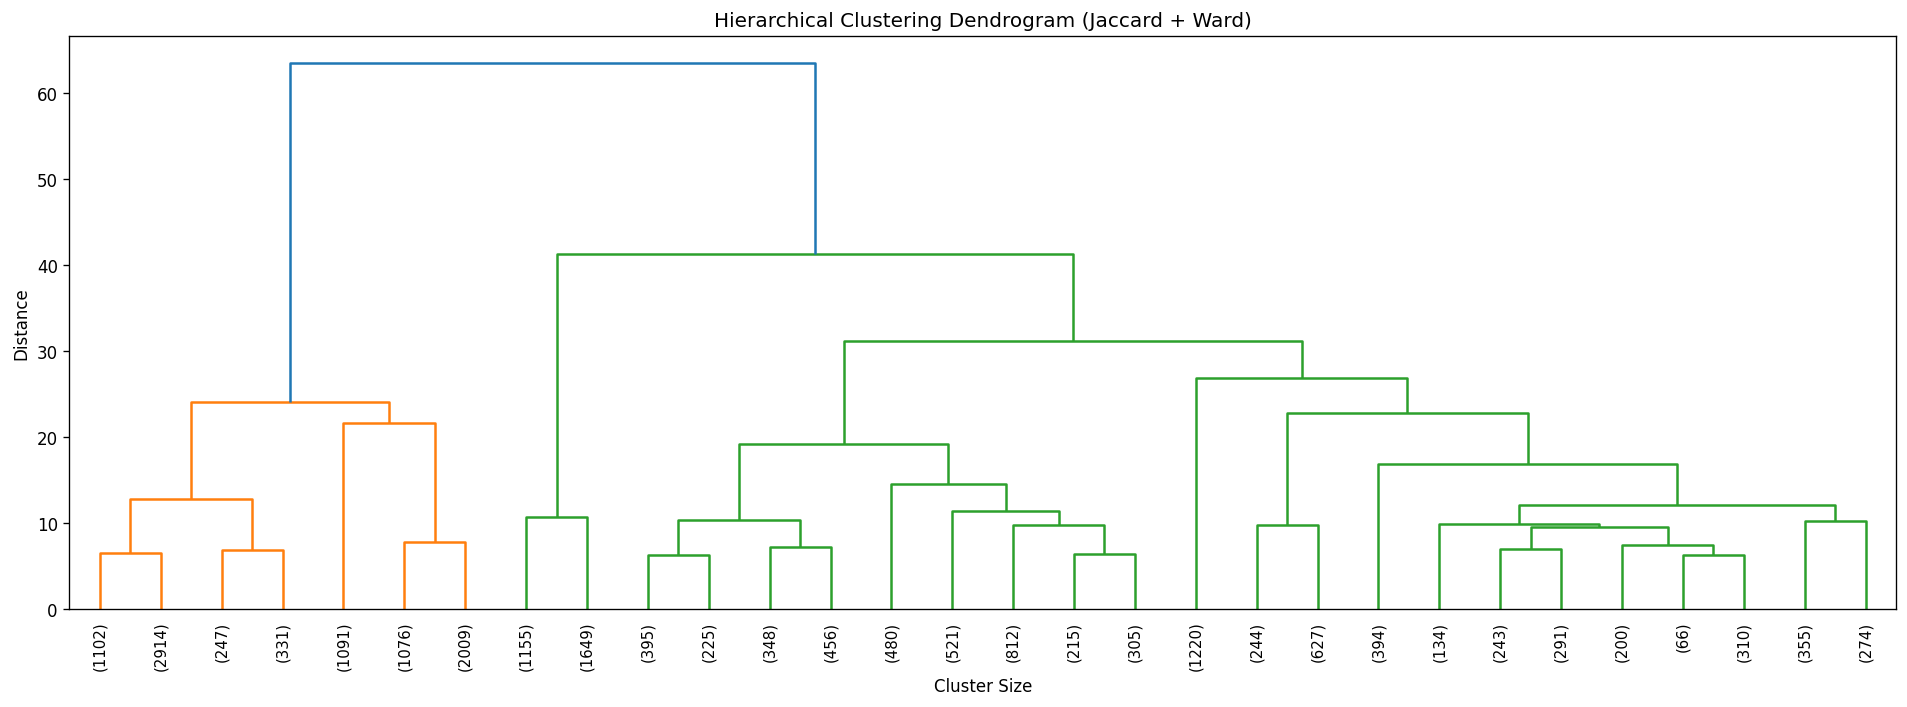

In [9]:
# Dendrogram to visualize cluster structure and choose cut
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax,
    color_threshold=0.7 * max(Z[:, 2]),
)
ax.set_title("Hierarchical Clustering Dendrogram (Jaccard + Ward)")
ax.set_xlabel("Cluster Size")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "dendrogram.png", bbox_inches="tight")
plt.show()

In [10]:
# Try different numbers of clusters and compute failure enrichment
results = []
for k in range(2, 11):
    cluster_labels = fcluster(Z, t=k, criterion="maxclust")
    row = {"k": k}
    for c in range(1, k + 1):
        mask = cluster_labels == c
        n_total = mask.sum()
        n_fail = labels_anomalous[mask].sum()
        row[f"C{c}_n"] = n_total
        row[f"C{c}_fail%"] = round(100 * n_fail / max(n_total, 1), 1)
    results.append(row)

results_df = pd.DataFrame(results).set_index("k")
print("Cluster sizes and failure rates for different k:")
results_df

Cluster sizes and failure rates for different k:


,C1_n,C1_fail%,C2_n,C2_fail%,C3_n,C3_fail%,C4_n,C4_fail%,C5_n,C5_fail%,C6_n,C6_fail%,C7_n,C7_fail%,C8_n,C8_fail%,C9_n,C9_fail%,C10_n,C10_fail%
k,,,,,,,,,,,,,,,,,,,,
2,8770,3.8,10919,1.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8770,3.8,2804,1.5,8115.0,1.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8770,3.8,2804,1.5,3757.0,0.5,4358.0,1.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,8770,3.8,2804,1.5,3757.0,0.5,1220.0,0.2,3138.0,2.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4594,4.7,4176,2.7,2804.0,1.5,3757.0,0.5,1220.0,0.2,3138.0,2.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4594,4.7,4176,2.7,2804.0,1.5,3757.0,0.5,1220.0,0.2,871.0,3.7,2267.0,1.9,NaN,NaN,NaN,NaN,NaN,NaN
8,4594,4.7,1091,0.1,3085.0,3.6,2804.0,1.5,3757.0,0.5,1220.0,0.2,871.0,3.7,2267.0,1.9,NaN,NaN,NaN,NaN
9,4594,4.7,1091,0.1,3085.0,3.6,2804.0,1.5,1424.0,0.3,2333.0,0.6,1220.0,0.2,871.0,3.7,2267.0,1.9,NaN,NaN
10,4594,4.7,1091,0.1,3085.0,3.6,2804.0,1.5,1424.0,0.3,2333.0,0.6,1220.0,0.2,871.0,3.7,394.0,8.6,1873.0,0.4


In [11]:
# Choose number of clusters based on dendrogram + failure separation
# Adjust N_CLUSTERS after inspecting the dendrogram and table above
N_CLUSTERS = 4

cluster_labels = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")
act_anomalous["cluster"] = cluster_labels
act_anomalous["label"] = labels_anomalous
act_anomalous["window_end"] = window_ends_anomalous

print(f"Chosen k={N_CLUSTERS}")
for c in range(1, N_CLUSTERS + 1):
    mask = cluster_labels == c
    n = mask.sum()
    n_fail = labels_anomalous[mask].sum()
    print(f"  Cluster {c}: {n:>5} windows, {n_fail:>3} pre-failure ({100*n_fail/max(n,1):.1f}%)")

Chosen k=4
  Cluster 1:  8770 windows, 329 pre-failure (3.8%)
  Cluster 2:  2804 windows,  41 pre-failure (1.5%)
  Cluster 3:  3757 windows,  19 pre-failure (0.5%)
  Cluster 4:  4358 windows,  77 pre-failure (1.8%)


## 7. Cluster Characterization

For each cluster, identify which sensors are most frequently activated and which subsystems they belong to.

In [12]:
# Per-cluster sensor activation profiles
cluster_profiles = {}
for c in range(1, N_CLUSTERS + 1):
    mask = act_anomalous["cluster"] == c
    profile = act_anomalous.loc[mask, sensors].mean()
    cluster_profiles[f"C{c}"] = profile

profiles_df = pd.DataFrame(cluster_profiles)
profiles_df["subsystem"] = [sensor_to_subsystem.get(s, "Unknown") for s in sensors]

# Show top activated sensors per cluster
for c in range(1, N_CLUSTERS + 1):
    col = f"C{c}"
    top = profiles_df[col].nlargest(10)
    print(f"\n--- Cluster {c}: Top 10 activated sensors ---")
    for sensor_name, rate in top.items():
        ss = sensor_to_subsystem.get(sensor_name, "?")
        print(f"  {sensor_name:<55} {ss:<12} {100*rate:5.1f}%")


--- Cluster 1: Top 10 activated sensors ---
  MW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE2                  Brake         99.3%
  MW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1                  Brake         99.0%
  MW3_PNEUMATIC_BRAKING_FORCE_BOGIE1                      Brake         98.9%
  MW1_PNEUMATIC_BRAKING_FORCE_BOGIE1                      Brake         98.7%
  MW3_PROPORTIONAL_VALVE_PRESSURE_BOGIE1                  Brake         98.7%
  MW2_PROPORTIONAL_VALVE_PRESSURE_BOGIE2                  Brake         98.4%
  MW4_PROPORTIONAL_VALVE_PRESSURE_BOGIE2                  Brake         98.1%
  MW1_PNEUMATIC_BRAKING_FORCE_BOGIE2                      Brake         97.8%
  MW2_PNEUMATIC_BRAKING_FORCE_BOGIE2                      Brake         97.4%
  MW4_PROPORTIONAL_VALVE_PRESSURE_BOGIE1                  Brake         97.2%

--- Cluster 2: Top 10 activated sensors ---
  MW1_SPRING_BRAKE_PRESSURE_BOGIE1                        Brake         99.5%
  CW2_SPRING_BRAKE_PRESSURE_BOGIE2                  

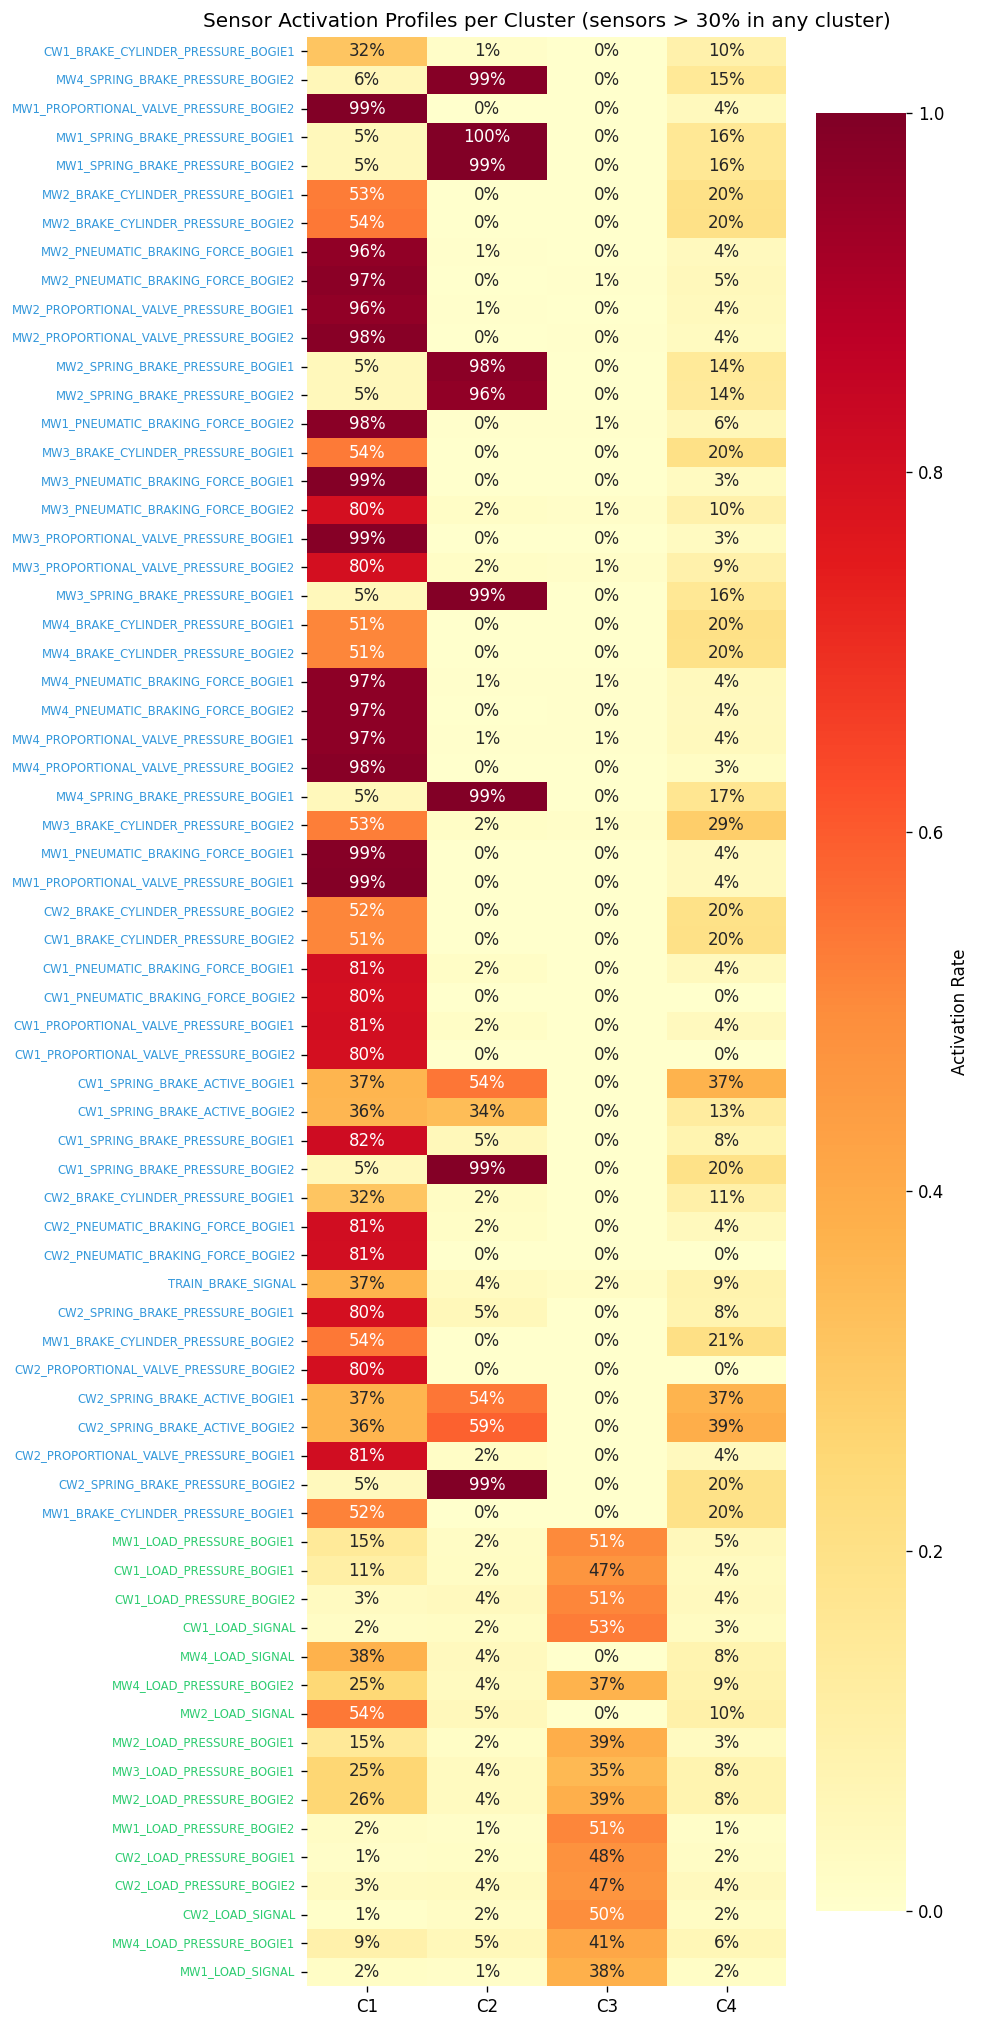

In [13]:
# Heatmap: cluster activation profiles
# Only show sensors activated > 30% in at least one cluster
threshold = 0.3
active_in_any = profiles_df[list(cluster_profiles.keys())].max(axis=1) > threshold
plot_data = profiles_df.loc[active_in_any, list(cluster_profiles.keys())].copy()
plot_data["subsystem"] = profiles_df.loc[active_in_any, "subsystem"]
plot_data = plot_data.sort_values("subsystem")

fig, ax = plt.subplots(figsize=(8, max(6, len(plot_data) * 0.25)))
sns.heatmap(
    plot_data[list(cluster_profiles.keys())],
    annot=True, fmt=".0%", cmap="YlOrRd",
    yticklabels=True, ax=ax, vmin=0, vmax=1,
    cbar_kws={"label": "Activation Rate"}
)

# Color y-tick labels by subsystem
subsystem_colors = {
    "APU": "#e74c3c", "Brake": "#3498db", "Leveling": "#2ecc71",
    "Traction": "#f39c12", "Context": "#9b59b6", "Unknown": "#95a5a6"
}
for tick_label in ax.get_yticklabels():
    sensor_name = tick_label.get_text()
    ss = sensor_to_subsystem.get(sensor_name, "Unknown")
    tick_label.set_color(subsystem_colors.get(ss, "black"))
    tick_label.set_fontsize(7)

ax.set_title("Sensor Activation Profiles per Cluster (sensors > 30% in any cluster)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cluster_activation_heatmap.png", bbox_inches="tight")
plt.show()

In [14]:
# Subsystem composition of each cluster
print("Subsystem composition per cluster (fraction of activated sensors belonging to each subsystem):\n")

for c in range(1, N_CLUSTERS + 1):
    col = f"C{c}"
    # Weight each sensor by its activation rate in this cluster
    weights = profiles_df[col]
    subsystems = profiles_df["subsystem"]
    
    subsystem_weight = {}
    for ss in subsystems.unique():
        mask = subsystems == ss
        subsystem_weight[ss] = weights[mask].sum()
    
    total = sum(subsystem_weight.values())
    print(f"Cluster {c}:")
    for ss, w in sorted(subsystem_weight.items(), key=lambda x: -x[1]):
        pct = 100 * w / total if total > 0 else 0
        bar = '#' * int(pct / 2)
        print(f"  {ss:<12} {pct:5.1f}%  {bar}")
    print()

Subsystem composition per cluster (fraction of activated sensors belonging to each subsystem):

Cluster 1:
  Brake         92.3%  ##############################################
  Leveling       7.1%  ###
  Context        0.4%  
  APU            0.3%  
  Traction       0.0%  

Cluster 2:
  Brake         91.0%  #############################################
  Leveling       5.2%  ##
  APU            2.3%  #
  Context        1.2%  
  Traction       0.3%  

Cluster 3:
  Leveling      92.4%  ##############################################
  Brake          4.0%  ##
  Context        2.4%  #
  APU            0.8%  
  Traction       0.4%  

Cluster 4:
  Brake         80.6%  ########################################
  Leveling      12.8%  ######
  APU            3.3%  #
  Context        3.1%  #
  Traction       0.2%  



## 8. Temporal Pattern Analysis

Analyze when each cluster's anomaly patterns appear relative to failure events.

Key questions:
- Do certain clusters appear consistently before failures (precursors)?
- What is the typical lead time between cluster occurrence and failure onset?
- Do clusters show temporal ordering (e.g., Cluster A appears first, then Cluster B)?

In [15]:
# Parse failure intervals for temporal analysis
import glob
from datetime import timedelta

FAILURE_CSV = ROOT / "data" / "asset_data" / "failure.csv"

fail_df = pd.read_csv(FAILURE_CSV, sep=";", encoding="utf-8")
failure_intervals = []
for _, row in fail_df.iterrows():
    try:
        start = pd.to_datetime(f"{row.iloc[0]} {row.iloc[1]}", dayfirst=True)
        end = pd.to_datetime(f"{row.iloc[2]} {row.iloc[3]}", dayfirst=True)
        failure_intervals.append((start, end))
    except Exception:
        continue
failure_intervals.sort(key=lambda x: x[0])

# Filter to dev period only
DEV_START = pd.Timestamp("2024-06-01")
DEV_END = pd.Timestamp("2025-02-11")
dev_failures = [(s, e) for s, e in failure_intervals if s >= DEV_START and s < DEV_END]
print(f"Failure intervals in dev period: {len(dev_failures)}")
for i, (s, e) in enumerate(dev_failures):
    duration = (e - s).total_seconds() / 3600
    print(f"  F{i+1}: {s.strftime('%Y-%m-%d %H:%M')} - {e.strftime('%Y-%m-%d %H:%M')} ({duration:.1f}h)")

Failure intervals in dev period: 16
  F1: 2024-06-27 15:47 - 2024-06-27 17:52 (2.1h)
  F2: 2024-08-19 10:37 - 2024-08-19 12:05 (1.5h)
  F3: 2024-08-19 10:38 - 2024-08-19 13:06 (2.5h)
  F4: 2024-08-19 10:39 - 2024-08-19 13:34 (2.9h)
  F5: 2024-08-27 15:58 - 2024-08-28 21:29 (29.5h)
  F6: 2024-08-27 19:47 - 2024-08-28 18:09 (22.4h)
  F7: 2024-08-27 19:48 - 2024-08-28 16:13 (20.4h)
  F8: 2024-08-28 14:54 - 2024-08-28 20:46 (5.9h)
  F9: 2024-09-03 05:04 - 2024-09-03 07:33 (2.5h)
  F10: 2024-09-22 05:49 - 2024-09-22 08:23 (2.6h)
  F11: 2024-10-06 00:11 - 2024-10-08 09:15 (57.1h)
  F12: 2024-10-10 10:40 - 2024-10-10 15:35 (4.9h)
  F13: 2024-10-28 15:31 - 2024-10-28 16:52 (1.3h)
  F14: 2024-10-31 12:54 - 2024-10-31 18:26 (5.5h)
  F15: 2024-12-14 17:43 - 2024-12-14 23:36 (5.9h)
  F16: 2025-01-21 06:11 - 2025-01-21 09:45 (3.6h)


In [16]:
# Compute lead time: for each anomalous window, time to next failure start
window_ends_ts = pd.to_datetime(act_anomalous["window_end"])

def time_to_next_failure(ts, failures):
    """Return hours until next failure start, or NaN if none."""
    for start, end in failures:
        if start > ts:
            return (start - ts).total_seconds() / 3600
        if start <= ts <= end:
            return 0.0  # currently in failure
    return np.nan

act_anomalous["hours_to_failure"] = [
    time_to_next_failure(ts, failure_intervals) for ts in window_ends_ts
]

# Lead time statistics per cluster
print("Lead time to next failure (hours) per cluster:\n")
for c in range(1, N_CLUSTERS + 1):
    mask = act_anomalous["cluster"] == c
    lead_times = act_anomalous.loc[mask, "hours_to_failure"].dropna()
    within_24h = (lead_times <= 24).sum()
    within_6h = (lead_times <= 6.2).sum()
    print(f"  Cluster {c}: n={len(lead_times)}, "
          f"median={lead_times.median():.1f}h, "
          f"within 6.2h={within_6h} ({100*within_6h/max(len(lead_times),1):.1f}%), "
          f"within 24h={within_24h} ({100*within_24h/max(len(lead_times),1):.1f}%)")

Lead time to next failure (hours) per cluster:

  Cluster 1: n=8770, median=365.1h, within 6.2h=329 (3.8%), within 24h=519 (5.9%)
  Cluster 2: n=2804, median=365.1h, within 6.2h=41 (1.5%), within 24h=127 (4.5%)
  Cluster 3: n=3757, median=406.5h, within 6.2h=19 (0.5%), within 24h=158 (4.2%)
  Cluster 4: n=4358, median=332.7h, within 6.2h=77 (1.8%), within 24h=348 (8.0%)


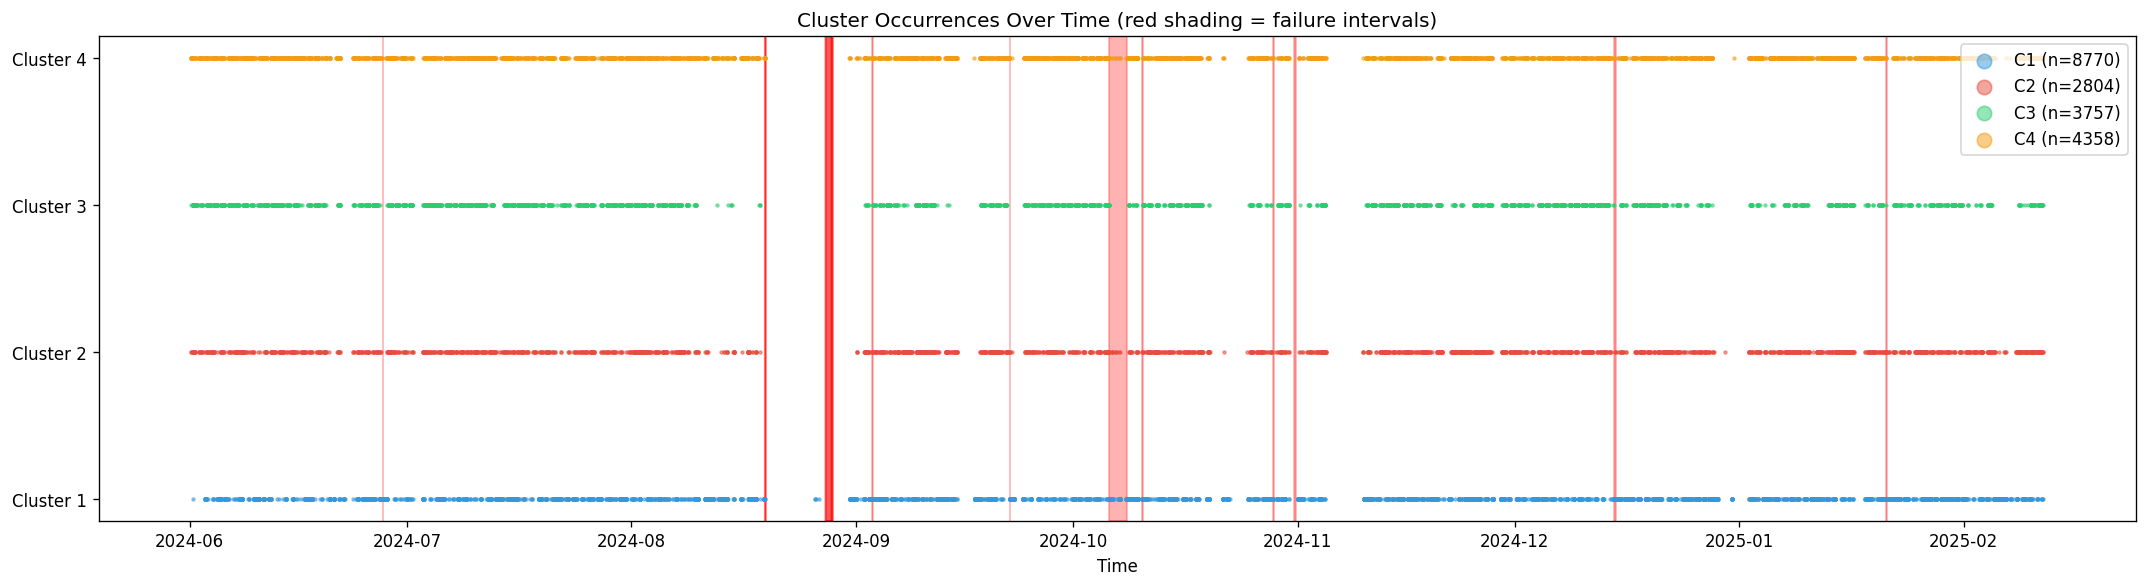

In [17]:
# Timeline visualization: cluster occurrences and failure events
fig, ax = plt.subplots(figsize=(18, 5))

cluster_colors = {1: "#3498db", 2: "#e74c3c", 3: "#2ecc71", 4: "#f39c12",
                  5: "#9b59b6", 6: "#1abc9c", 7: "#e67e22", 8: "#34495e"}

for c in range(1, N_CLUSTERS + 1):
    mask = act_anomalous["cluster"] == c
    times = pd.to_datetime(act_anomalous.loc[mask, "window_end"])
    ax.scatter(times, [c] * len(times), s=3, alpha=0.5,
               color=cluster_colors.get(c, "gray"), label=f"C{c} (n={mask.sum()})")

# Mark failure intervals
for start, end in dev_failures:
    ax.axvspan(start, end, alpha=0.3, color="red", zorder=0)

ax.set_yticks(range(1, N_CLUSTERS + 1))
ax.set_yticklabels([f"Cluster {c}" for c in range(1, N_CLUSTERS + 1)])
ax.set_xlabel("Time")
ax.set_title("Cluster Occurrences Over Time (red shading = failure intervals)")
ax.legend(loc="upper right", markerscale=5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cluster_timeline.png", bbox_inches="tight")
plt.show()

C:\Users\Emırhan\AppData\Local\Temp\ipykernel_17308\2997680434.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(lead_data, labels=[f"C{c}" for c in range(1, N_CLUSTERS + 1)],


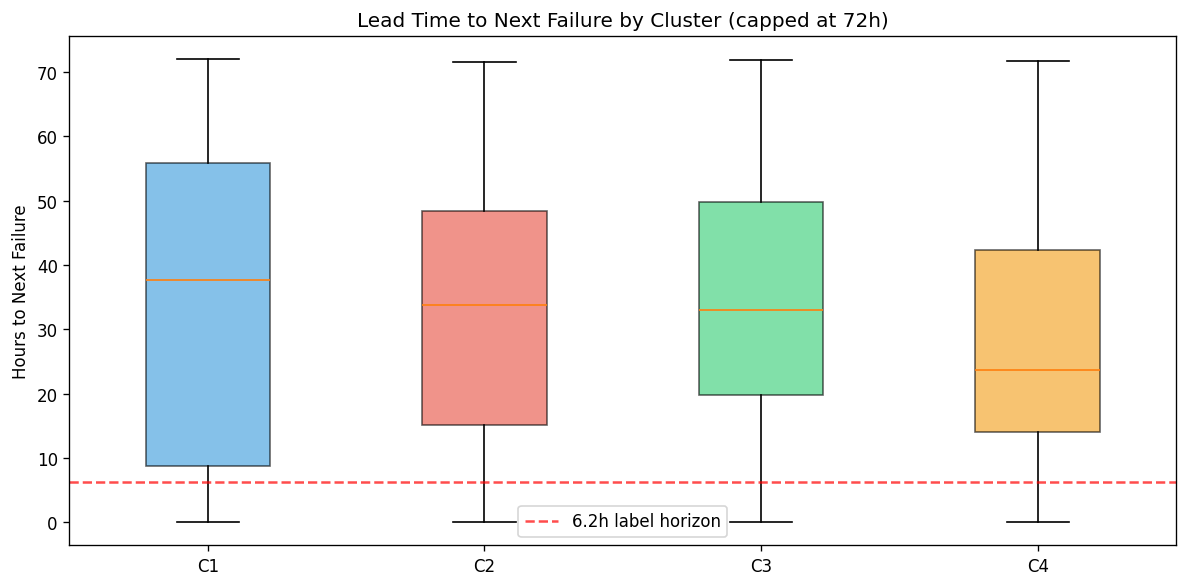

In [18]:
# Lead time distribution per cluster (box plot)
fig, ax = plt.subplots(figsize=(10, 5))

lead_data = []
for c in range(1, N_CLUSTERS + 1):
    mask = act_anomalous["cluster"] == c
    lt = act_anomalous.loc[mask, "hours_to_failure"].dropna()
    lt_clipped = lt[lt <= 72]  # clip to 72h for visibility
    lead_data.append(lt_clipped)

bp = ax.boxplot(lead_data, labels=[f"C{c}" for c in range(1, N_CLUSTERS + 1)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(cluster_colors.get(i + 1, "gray"))
    patch.set_alpha(0.6)

ax.axhline(y=6.2, color="red", linestyle="--", alpha=0.7, label="6.2h label horizon")
ax.set_ylabel("Hours to Next Failure")
ax.set_title("Lead Time to Next Failure by Cluster (capped at 72h)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cluster_lead_times.png", bbox_inches="tight")
plt.show()

## 9. Pre-Failure Temporal Sequences

For each failure event, look at the 24 hours before failure onset and analyze which clusters appear and in what order.

In [19]:
# For each failure, find cluster occurrences in the 24h window before failure start
LOOKBACK_H = 24

print(f"Pre-failure analysis: {LOOKBACK_H}h lookback before each failure\n")

for i, (f_start, f_end) in enumerate(dev_failures):
    lookback_start = f_start - timedelta(hours=LOOKBACK_H)
    
    # Find anomalous windows in the lookback period
    times = pd.to_datetime(act_anomalous["window_end"])
    in_lookback = (times >= lookback_start) & (times < f_start)
    
    if not in_lookback.any():
        print(f"F{i+1} ({f_start.strftime('%Y-%m-%d %H:%M')}): No anomalous windows in lookback")
        continue
    
    pre_failure = act_anomalous[in_lookback]
    cluster_seq = pre_failure["cluster"].values
    cluster_counts = pd.Series(cluster_seq).value_counts().sort_index()
    
    hours_before = [(f_start - t).total_seconds() / 3600 for t in times[in_lookback]]
    
    print(f"F{i+1} ({f_start.strftime('%Y-%m-%d %H:%M')}): "
          f"{len(pre_failure)} anomalous windows")
    for c, cnt in cluster_counts.items():
        c_mask = pre_failure["cluster"] == c
        c_hours = [h for h, m in zip(hours_before, c_mask.values) if m]
        print(f"  C{c}: {cnt} windows, "
              f"earliest {max(c_hours):.1f}h before, "
              f"latest {min(c_hours):.1f}h before")
    print()

Pre-failure analysis: 24h lookback before each failure

F1 (2024-06-27 15:47): 112 anomalous windows
  C1: 65 windows, earliest 14.3h before, latest 0.1h before
  C2: 11 windows, earliest 21.4h before, latest 7.2h before
  C3: 20 windows, earliest 24.0h before, latest 8.8h before
  C4: 16 windows, earliest 22.1h before, latest 0.4h before

F2 (2024-08-19 10:37): 31 anomalous windows
  C1: 14 windows, earliest 16.2h before, latest 1.9h before
  C2: 1 windows, earliest 17.2h before, latest 17.2h before
  C3: 3 windows, earliest 18.9h before, latest 17.8h before
  C4: 13 windows, earliest 23.5h before, latest 0.0h before

F3 (2024-08-19 10:38): 31 anomalous windows
  C1: 14 windows, earliest 16.2h before, latest 1.9h before
  C2: 1 windows, earliest 17.2h before, latest 17.2h before
  C3: 3 windows, earliest 18.9h before, latest 17.8h before
  C4: 13 windows, earliest 23.5h before, latest 0.0h before

F4 (2024-08-19 10:39): 31 anomalous windows
  C1: 14 windows, earliest 16.2h before, lat

## 10. Cluster Summary & Subsystem Mapping

Summarize each cluster with:
- Defining sensors (activation rate > 50%)
- Dominant subsystem(s)
- Failure enrichment
- Interpretation for expert verification

In [20]:
# Build summary table
summary_rows = []

for c in range(1, N_CLUSTERS + 1):
    col = f"C{c}"
    mask = act_anomalous["cluster"] == c
    n_windows = mask.sum()
    n_fail = act_anomalous.loc[mask, "label"].sum()
    fail_pct = 100 * n_fail / max(n_windows, 1)
    
    # Defining sensors (> 50% activation in cluster)
    profile = profiles_df[col]
    defining = profile[profile > 0.5].sort_values(ascending=False)
    defining_sensors = list(defining.index)
    
    # Dominant subsystems
    subsystems_involved = [sensor_to_subsystem.get(s, "?") for s in defining_sensors]
    dominant = pd.Series(subsystems_involved).value_counts()
    
    summary_rows.append({
        "Cluster": f"C{c}",
        "Windows": n_windows,
        "Failure %": f"{fail_pct:.1f}%",
        "Defining Sensors": len(defining_sensors),
        "Dominant Subsystems": ", ".join(f"{ss}({n})" for ss, n in dominant.items()),
        "Top Sensors": ", ".join(defining_sensors[:5]),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Cluster,Windows,Failure %,Defining Sensors,Dominant Subsystems,Top Sensors
0,C1,8770,3.8%,37,"Brake(36), Leveling(1)","MW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE2, MW1_PR..."
1,C2,2804,1.5%,12,Brake(12),"MW1_SPRING_BRAKE_PRESSURE_BOGIE1, CW2_SPRING_B..."
2,C3,3757,0.5%,4,Leveling(4),"CW1_LOAD_SIGNAL, CW1_LOAD_PRESSURE_BOGIE2, MW1..."
3,C4,4358,1.8%,0,,


In [21]:
# Save cluster definitions for Phase 2
import json

cluster_definitions = {}
for c in range(1, N_CLUSTERS + 1):
    col = f"C{c}"
    profile = profiles_df[col]
    defining = profile[profile > 0.5].sort_values(ascending=False)
    mask = act_anomalous["cluster"] == c
    n_windows = int(mask.sum())
    n_fail = int(act_anomalous.loc[mask, "label"].sum())
    
    cluster_definitions[f"C{c}"] = {
        "sensors": list(defining.index),
        "subsystems": list(set(sensor_to_subsystem.get(s, "?") for s in defining.index)),
        "n_windows": n_windows,
        "n_failure": n_fail,
        "failure_rate": round(n_fail / max(n_windows, 1), 4),
        "activation_rates": {s: round(float(r), 3) for s, r in defining.items()},
    }

out_path = ROOT / "outputs" / "cluster_definitions.json"
with open(out_path, "w") as f:
    json.dump(cluster_definitions, f, indent=2)
print(f"Saved cluster definitions to {out_path}")

# Print for review
for name, defn in cluster_definitions.items():
    print(f"\n{name}: {defn['n_windows']} windows, "
          f"{100*defn['failure_rate']:.1f}% failure, "
          f"subsystems={defn['subsystems']}")
    print(f"  Sensors ({len(defn['sensors'])}): {', '.join(defn['sensors'][:8])}{'...' if len(defn['sensors']) > 8 else ''}")

Saved cluster definitions to C:\Users\Emırhan\Desktop\MASTER THESIS\Kurtulus-thesis\outputs\cluster_definitions.json

C1: 8770 windows, 3.8% failure, subsystems=['Leveling', 'Brake']
  Sensors (37): MW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE2, MW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1, MW3_PNEUMATIC_BRAKING_FORCE_BOGIE1, MW1_PNEUMATIC_BRAKING_FORCE_BOGIE1, MW3_PROPORTIONAL_VALVE_PRESSURE_BOGIE1, MW2_PROPORTIONAL_VALVE_PRESSURE_BOGIE2, MW4_PROPORTIONAL_VALVE_PRESSURE_BOGIE2, MW1_PNEUMATIC_BRAKING_FORCE_BOGIE2...

C2: 2804 windows, 1.5% failure, subsystems=['Brake']
  Sensors (12): MW1_SPRING_BRAKE_PRESSURE_BOGIE1, CW2_SPRING_BRAKE_PRESSURE_BOGIE2, MW1_SPRING_BRAKE_PRESSURE_BOGIE2, MW4_SPRING_BRAKE_PRESSURE_BOGIE1, MW3_SPRING_BRAKE_PRESSURE_BOGIE1, CW1_SPRING_BRAKE_PRESSURE_BOGIE2, MW4_SPRING_BRAKE_PRESSURE_BOGIE2, MW2_SPRING_BRAKE_PRESSURE_BOGIE1...

C3: 3757 windows, 0.5% failure, subsystems=['Leveling']
  Sensors (4): CW1_LOAD_SIGNAL, CW1_LOAD_PRESSURE_BOGIE2, MW1_LOAD_PRESSURE_BOGIE2, MW1_LO

## 11. Validation on Test Set

Apply the same z-score thresholds and cluster assignments to the test set to check if the patterns generalize.

In [22]:
# Z-score test set using train-normal statistics
z_test = pd.DataFrame(index=test.index)
for col in feature_cols:
    mu = normal[col].mean()
    sd = normal[col].std()
    if sd < 1e-10:
        z_test[col] = 0.0
    else:
        z_test[col] = (test[col] - mu) / sd

# Activation matrix for test
act_test = pd.DataFrame(0, index=test.index, columns=sensors)
for sensor in sensors:
    sensor_feats = [c for c in feature_cols if any(c == sensor + suf for suf in suffixes)]
    if sensor_feats:
        max_abs_z = z_test[sensor_feats].abs().max(axis=1)
        act_test[sensor] = (max_abs_z > Z_THRESH).astype(int)

n_act_test = act_test.sum(axis=1)
test_anomalous = n_act_test >= MIN_ACTIVATED_SENSORS
test_labels = test["label"].values

print(f"Test set: {len(test)} windows")
print(f"Anomalous (>= {MIN_ACTIVATED_SENSORS} sensors): {test_anomalous.sum()} ({100*test_anomalous.mean():.1f}%)")
print(f"Test failure rate overall: {100*test_labels.mean():.2f}%")
print(f"Test failure rate in anomalous: {100*test_labels[test_anomalous].mean():.2f}%")

C:\Users\Emırhan\AppData\Local\Temp\ipykernel_17308\1569364388.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  z_test[col] = (test[col] - mu) / sd
C:\Users\Emırhan\AppData\Local\Temp\ipykernel_17308\1569364388.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  z_test[col] = (test[col] - mu) / sd
C:\Users\Emırhan\AppData\Local\Temp\ipykernel_17308\1569364388.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

Test set: 21554 windows
Anomalous (>= 3 sensors): 19931 (92.5%)
Test failure rate overall: 2.70%
Test failure rate in anomalous: 2.62%


In [23]:
# Assign test anomalous windows to nearest cluster using Jaccard distance to cluster centroids
from scipy.spatial.distance import cdist

# Compute cluster centroids (mean activation profile, then binarize at 0.5)
centroids = np.array([profiles_df[f"C{c}"].values for c in range(1, N_CLUSTERS + 1)])

act_test_anom = act_test[test_anomalous].values
test_labels_anom = test_labels[test_anomalous]

# Assign to nearest centroid using cosine similarity (works better than Jaccard for continuous centroids)
distances = cdist(act_test_anom, centroids, metric="cosine")
test_cluster_labels = distances.argmin(axis=1) + 1

print("Test set cluster assignments:")
for c in range(1, N_CLUSTERS + 1):
    mask = test_cluster_labels == c
    n = mask.sum()
    n_fail = test_labels_anom[mask].sum()
    print(f"  C{c}: {n:>5} windows, {n_fail:>3} pre-failure ({100*n_fail/max(n,1):.1f}%)")

print(f"\nComparison: do failure rates per cluster generalize from train to test?")

Test set cluster assignments:
  C1:  8670 windows, 334 pre-failure (3.9%)
  C2:  1466 windows,  25 pre-failure (1.7%)
  C3:  6653 windows,  55 pre-failure (0.8%)
  C4:  3142 windows, 108 pre-failure (3.4%)

Comparison: do failure rates per cluster generalize from train to test?


## Summary

**What was done:**
1. Z-score anomaly detection identified anomalous windows where sensors deviate from normal operation
2. Hierarchical clustering (Jaccard + Ward) found recurring anomaly patterns
3. Each cluster maps to specific subsystems (Brake, APU, Leveling, etc.)
4. Temporal analysis shows which patterns appear as failure precursors
5. Cluster definitions saved for constructing subsystem-aware feature representations

**Next steps (Phase 2):**
- Review cluster definitions with domain experts (Wiener Linien)
- Construct subsystem-specific datasets from verified clusters
- Train models (RF, LSTM-AE) on both subsystem-aware and full-feature representations
- Compare performance under identical experimental conditions